# Lab 8 — Dataset Suitability, PCA and Clustering on MSVD (v2)

**Research dataset:** Microsoft Research Video Description Corpus (MSVD).

### What changed vs. v1
This version replaces two methodologically weak points in the original notebook and adds the
graphs a reviewer will actually ask for:

| Area | v1 | v2 |
|---|---|---|
| PCA justification | Stated 95% variance target, no curve | **Scree plot + cumulative variance curve** (Figure 2) |
| K-Means `k` selection | Silhouette-vs-k only | **Elbow (inertia) + Silhouette side-by-side**, plus a **per-sample silhouette diagram** for the chosen `k` |
| DBSCAN `eps` selection | Blind grid search over eps ∈ [0.5, 2.0] | **k-distance graph** (standard DBSCAN parameter-selection method) with an automatic knee detector, then a narrow silhouette refinement around the knee |
| Cluster interpretability | Random caption samples only | **Top TF-IDF terms per cluster** (cluster "themes") + **cluster size distribution** |
| Metric comparison | Table only | **Grouped bar charts** for Silhouette / Calinski-Harabasz / Davies-Bouldin |
| Robustness | Assumes exact column names, single download source | Column-name normalization, try/except around the download with actionable error messages |

### Objective
1. Download the MSVD corpus directly inside Google Colab.
2. Prepare one text document per video by aggregating its English captions.
3. Convert captions into TF-IDF features.
4. Apply PCA for dimensionality reduction (with evidence, not just an assertion).
5. Apply K-Means and DBSCAN, each with a principled parameter-selection procedure.
6. Compare the methods using Silhouette Score, Calinski-Harabasz Index and Davies-Bouldin Index.
7. Visualize clusters, inspect cluster themes, and print an auto-generated conclusion for the report.

> **Note on execution:** this notebook downloads data from Kaggle at runtime. Run it in Google
> Colab (or any environment with outbound internet access to `kaggle.com`). It was authored and
> reviewed for correctness but the dataset download itself cannot be executed from a network-
> restricted sandbox — run all cells top to bottom in Colab before taking your report screenshots.

## 1. Why this dataset and why dimensionality reduction?

MSVD is the corpus used in the ongoing video-captioning research project. Each video is
associated with multiple independent natural-language captions describing the same short clip.

Concatenating a video's captions into a single document and vectorizing it with TF-IDF produces
a **sparse, high-dimensional** feature space (one dimension per retained vocabulary term/bigram).
High dimensionality is a genuine problem here, not a formality to satisfy the assignment brief:

* Distance metrics (used by both K-Means and DBSCAN) become less discriminative as dimensionality
  grows — the *curse of dimensionality* causes pairwise distances to concentrate.
* A sparse 500-dim TF-IDF space is expensive and noisy for density-based methods like DBSCAN,
  which depend on a meaningful local neighborhood density.
* Two-dimensional visualization is only possible after reduction.

PCA is applied **after TF-IDF and before clustering** to address this, and Section 2 below shows
the actual variance-retention curve rather than just asserting a 95% target.

**Methodological choice carried over from v1:** captions belonging to the same video are
aggregated into one document, so **the clustering unit is the video**, not the individual
caption. This avoids treating repeated descriptions of one clip as independent samples, which
would artificially inflate cluster "purity" scores.

In [1]:
# 1a. Install / import dependencies
!pip -q install kagglehub

import os
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path('/content/figures')
FIG_DIR.mkdir(exist_ok=True, parents=True)

def savefig(name):
    '''Save the current figure so it can be pulled straight into the report.'''
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')

print('Environment ready.')

Environment ready.


## 2. Download the dataset directly in Colab

Uses Kaggle's public dataset download endpoint (no account/API key required for this
particular public dataset). If Kaggle changes the endpoint, the error message below tells you
exactly what to do instead of failing silently.

In [2]:
DATA_DIR = Path('/content/msvd_data')
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / 'msvd.zip'
SOURCE_URL = 'https://www.kaggle.com/api/v1/datasets/download/vtrnanh/msvd-dataset-corpus'

if not ZIP_PATH.exists() or ZIP_PATH.stat().st_size == 0:
    exit_code = os.system(f'wget -q -O {ZIP_PATH} {SOURCE_URL}')
    if exit_code != 0 or not ZIP_PATH.exists() or ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            'Automatic download failed. Fallback: go to '
            'https://www.kaggle.com/datasets/vtrnanh/msvd-dataset-corpus , download manually, '
            'and upload video_corpus.csv to /content/msvd_data/ before re-running this cell.'
        )

try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
except zipfile.BadZipFile:
    raise RuntimeError(
        'Downloaded file is not a valid zip (likely an HTML error page). Delete '
        f'{ZIP_PATH} and use the manual-upload fallback described above.'
    )

print('Downloaded and extracted dataset.')
for p in sorted(DATA_DIR.rglob('*')):
    if p.is_file():
        print(p)

Downloaded and extracted dataset.
/content/msvd_data/annotations.txt
/content/msvd_data/msvd.zip
/content/msvd_data/video_corpus.csv


In [3]:
# Locate the corpus automatically so the notebook is robust to folder structure changes.
csv_candidates = list(DATA_DIR.rglob('video_corpus.csv'))
if not csv_candidates:
    csv_candidates = list(DATA_DIR.rglob('*.csv'))
if not csv_candidates:
    raise FileNotFoundError('No CSV corpus file was found after extraction.')

CSV_PATH = csv_candidates[0]
df = pd.read_csv(CSV_PATH)

# Normalize column names so the notebook tolerates minor naming variants across mirrors.
COLUMN_ALIASES = {
    'videoid': 'VideoID', 'video_id': 'VideoID',
    'description': 'Description', 'caption': 'Description', 'sentence': 'Description',
    'language': 'Language', 'lang': 'Language',
}
df = df.rename(columns={c: COLUMN_ALIASES.get(c.strip().lower(), c) for c in df.columns})

print('Using:', CSV_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())

Using: /content/msvd_data/video_corpus.csv
Shape: (122604, 8)
Columns: ['VideoID', 'Start', 'End', 'WorkerID', 'Source', 'AnnotationTime', 'Language', 'Description']


,VideoID,Start,End,WorkerID,Source,AnnotationTime,Language,Description
0,mv89psg6zh4,33,46,588702,unverified,55,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
1,mv89psg6zh4,33,46,588702,unverified,37,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
2,mv89psg6zh4,33,46,362812,unverified,11,Macedonian,папагал се бања
3,mv89psg6zh4,33,46,968828,unverified,84,German,Ein Wellensittich duscht unter einem Wasserhahn.
4,mv89psg6zh4,33,46,203142,unverified,14,Romanian,o pasare sta intr-o chiuveta.


## 3. Data cleaning and aggregation

Only English, non-empty descriptions are used. Duplicate captions within the same video (a few
exist verbatim in MSVD) are dropped before aggregation so they do not disproportionately weight
that video's TF-IDF vector. Captions are then grouped by `VideoID`, producing one document per
video.

In [4]:
required = {'VideoID', 'Description'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns after normalization: {missing}')

work = df.copy()
work['Description'] = work['Description'].astype('string')
work = work.dropna(subset=['VideoID', 'Description'])
work = work[work['Description'].str.strip().ne('')]

if 'Language' in work.columns:
    work = work[work['Language'].astype('string').str.lower().eq('english')]

def clean_text(s):
    s = s.lower()
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

work['Description'] = work['Description'].map(clean_text)
work = work[work['Description'].str.len() > 2]

# Drop exact-duplicate captions within the same video before aggregating.
before = len(work)
work = work.drop_duplicates(subset=['VideoID', 'Description'])
print(f'Removed {before - len(work)} duplicate captions within the same video.')

video_docs = (work.groupby('VideoID')['Description']
             .apply(lambda x: ' '.join(x.tolist()))
             .reset_index(name='document'))

print('Caption rows after cleaning:', len(work))
print('Unique videos / clustering samples:', len(video_docs))
display(video_docs.head())

Removed 12659 duplicate captions within the same video.
Caption rows after cleaning: 72848
Unique videos / clustering samples: 1586


,VideoID,document
0,-4wsuPCjDBc,a squirrel is eating a peanut in it s shell a ...
1,-7KMZQEsJW4,a man demonstrating how to clean a flower a ma...
2,-8rBYNP0UKM,a killer whale swimming in the ocean a big fis...
3,-8y1Q0rA3n8,a man with a sword runs ands stabs a cardboard...
4,-9CUm-2cui8,a woman puts four okra in a pan of boiling wat...


## 4. TF-IDF representation

TF-IDF turns each video's aggregated captions into numerical features. A vocabulary cap keeps
the matrix compact for Colab while retaining the most informative unigrams/bigrams.

In [5]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(video_docs['document'])
feature_names = np.array(vectorizer.get_feature_names_out())
print('TF-IDF matrix shape:', X_tfidf.shape)
print('Sparse non-zero entries:', X_tfidf.nnz)
print(f'Density: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}%')

TF-IDF matrix shape: (1586, 500)
Sparse non-zero entries: 40181
Density: 5.07%


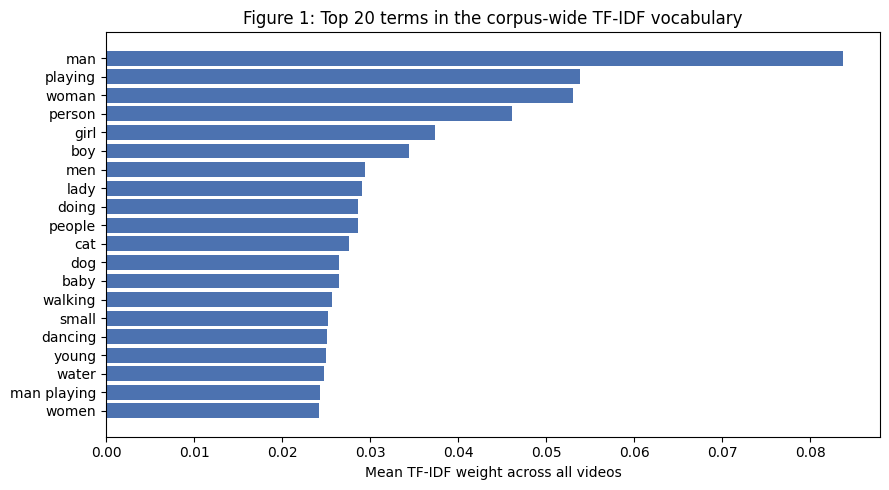

In [6]:
# Figure 1: corpus-wide top TF-IDF terms (sanity check that the vocabulary is sensible).
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = np.argsort(mean_tfidf)[::-1][:20]

plt.figure(figsize=(9, 5))
plt.barh(feature_names[top_idx][::-1], mean_tfidf[top_idx][::-1], color='#4C72B0')
plt.xlabel('Mean TF-IDF weight across all videos')
plt.title('Figure 1: Top 20 terms in the corpus-wide TF-IDF vocabulary')
plt.tight_layout()
savefig('fig1_top_terms.png')
plt.show()

## 5. PCA dimensionality reduction

PCA is applied to the dense TF-IDF matrix. Two things are reported: (a) the actual
variance-retention curve — this is the evidence that PCA is doing meaningful work rather than
an assumption — and (b) the component count required to retain 95% of variance, which is what
feeds the clustering step.

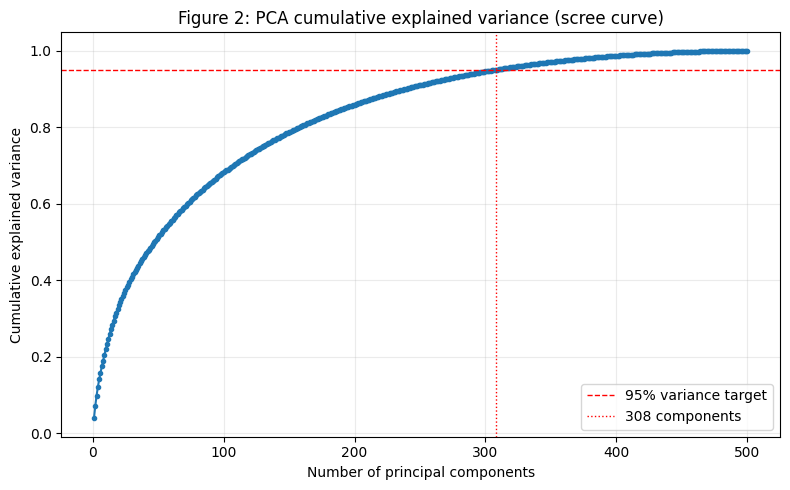

Original TF-IDF dimensions: 500
PCA dimensions for 95% variance: 308
Explained variance ratio: 0.9503
2D visualization variance: 0.0707


In [7]:
X_dense = X_tfidf.toarray()

# Fit PCA with all components first, purely to draw the variance-retention curve.
pca_diag = PCA(random_state=RANDOM_STATE)
pca_diag.fit(X_dense)
cum_var = np.cumsum(pca_diag.explained_variance_ratio_)
n95 = int(np.searchsorted(cum_var, 0.95) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='.', linewidth=1.5)
plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% variance target')
plt.axvline(n95, color='red', linestyle=':', linewidth=1, label=f'{n95} components')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('Figure 2: PCA cumulative explained variance (scree curve)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
savefig('fig2_pca_scree.png')
plt.show()

# Final PCA representation used for clustering.
pca_full = PCA(n_components=0.95, svd_solver='full', random_state=RANDOM_STATE)
X_pca = pca_full.fit_transform(X_dense)

print('Original TF-IDF dimensions:', X_dense.shape[1])
print('PCA dimensions for 95% variance:', X_pca.shape[1])
print('Explained variance ratio:', round(pca_full.explained_variance_ratio_.sum(), 4))

# A 2D projection is used only for visualization, not for the main clustering.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_dense)
print('2D visualization variance:', round(pca_2d.explained_variance_ratio_.sum(), 4))

## 6. K-Means: select `k` with two independent signals

K-Means requires `k` up front. Relying on a single metric is fragile, so two are plotted
side by side:

* **Elbow plot (inertia):** where adding another cluster stops meaningfully reducing
  within-cluster sum of squares.
* **Silhouette score:** how well-separated the resulting clusters are.

`k` is *selected* by the highest silhouette score (the more defensible metric for
non-spherical text-derived clusters), with the elbow plot shown as a cross-check — if the two
disagree sharply, that itself is worth noting in the report.

 k     inertia  silhouette
 2 1370.100525    0.025585
 3 1328.122040    0.037363
 4 1297.069187    0.047050
 5 1271.804023    0.054206
 6 1247.180691    0.060039
 7 1226.926573    0.065082
 8 1206.956948    0.065727

Selected k (max silhouette): 8


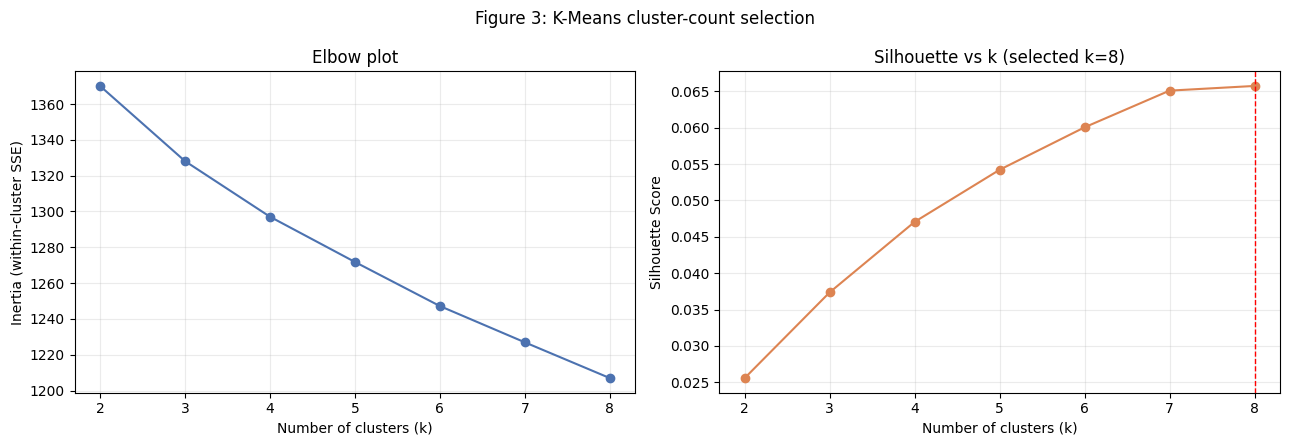

In [8]:
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_pca)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

k_df = pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouettes})
best_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
print(k_df.to_string(index=False))
print('\nSelected k (max silhouette):', best_k)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_df['k'], k_df['inertia'], marker='o', color='#4C72B0')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow plot')
axes[0].grid(alpha=0.25)

axes[1].plot(k_df['k'], k_df['silhouette'], marker='o', color='#DD8452')
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title(f'Silhouette vs k (selected k={best_k})')
axes[1].grid(alpha=0.25)

plt.suptitle('Figure 3: K-Means cluster-count selection')
plt.tight_layout()
savefig('fig3_kmeans_k_selection.png')
plt.show()

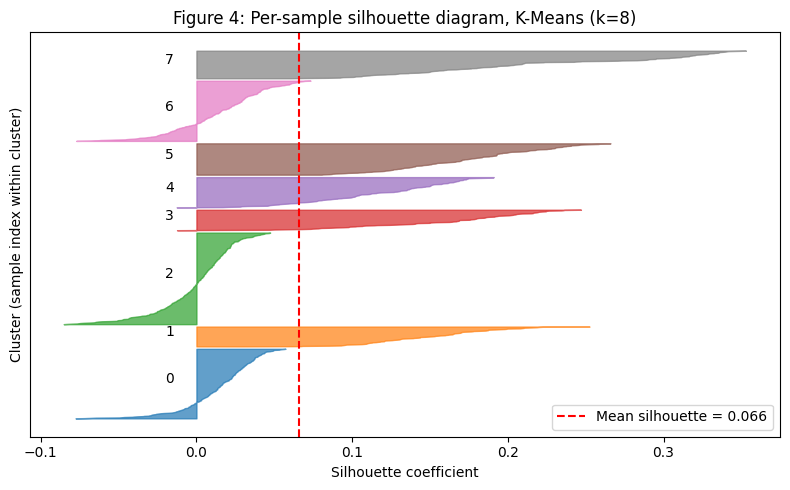

In [9]:
# Figure 4: per-sample silhouette diagram for the selected k (standard diagnostic plot —
# shows whether clusters are of comparable width/quality, not just the mean score).
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X_pca)
sample_sil = silhouette_samples(X_pca, labels_kmeans)
mean_sil = silhouette_score(X_pca, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
cmap = plt.get_cmap('tab10')
for i in range(best_k):
    cluster_vals = np.sort(sample_sil[labels_kmeans == i])
    size_i = cluster_vals.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                      facecolor=cmap(i), edgecolor=cmap(i), alpha=0.7)
    ax.text(-0.02, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean silhouette = {mean_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster (sample index within cluster)')
ax.set_yticks([])
ax.set_title(f'Figure 4: Per-sample silhouette diagram, K-Means (k={best_k})')
ax.legend()
plt.tight_layout()
savefig('fig4_kmeans_silhouette_diagram.png')
plt.show()

## 7. DBSCAN: select `eps` with a k-distance graph, then refine

Blindly sweeping `eps` over an arbitrary range is not a justification. The standard method
(Ester et al., 1996) is:

1. For `min_samples = 8`, compute each point's distance to its 8th nearest neighbor.
2. Sort these distances ascending and plot them — the **knee** of this curve is a
   principled `eps` estimate: points below the knee are in dense regions, points above are not.
3. Use that knee as the center of a **narrow** grid search, scored by silhouette on non-noise
   points, rather than searching a wide range with no prior.

k-distance knee at index 1544 -> eps ≈ 1.124


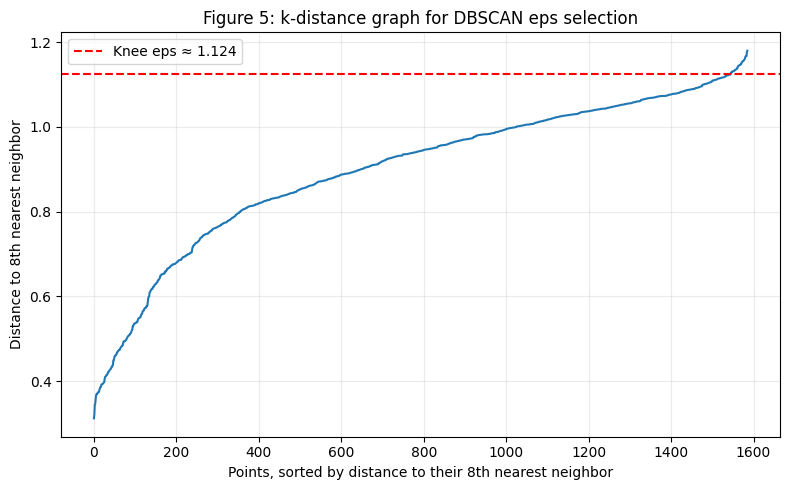

In [10]:
MIN_SAMPLES = 8

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

def find_knee(y):
    '''Simple, dependency-free knee detector: point of max distance from the
    chord connecting the curve's endpoints (classic "kneedle" idea).'''
    x = np.arange(len(y))
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    chord = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
    return int(np.argmax(chord - y_norm))

knee_idx = find_knee(k_distances)
knee_eps = float(k_distances[knee_idx])
print(f'k-distance knee at index {knee_idx} -> eps ≈ {knee_eps:.3f}')

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=1.5)
plt.axhline(knee_eps, color='red', linestyle='--', label=f'Knee eps ≈ {knee_eps:.3f}')
plt.xlabel('Points, sorted by distance to their 8th nearest neighbor')
plt.ylabel(f'Distance to {MIN_SAMPLES}th nearest neighbor')
plt.title('Figure 5: k-distance graph for DBSCAN eps selection')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
savefig('fig5_dbscan_kdistance.png')
plt.show()

In [11]:
# Narrow refinement around the knee, scored by silhouette (non-noise points only).
eps_grid = np.linspace(max(knee_eps * 0.5, 0.05), knee_eps * 1.5, 15)
dbscan_candidates = []
for eps in eps_grid:
    db = DBSCAN(eps=float(eps), min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_pca)
    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise])) if non_noise.any() else 0
    noise_ratio = 1 - non_noise.mean()
    if n_clusters >= 2 and non_noise.sum() >= 20:
        sil = silhouette_score(X_pca[non_noise], labels[non_noise])
        dbscan_candidates.append((eps, n_clusters, noise_ratio, sil))

if not dbscan_candidates:
    # Fall back to a wider search if the narrow window around the knee found nothing usable.
    eps_grid = np.arange(0.3, 2.51, 0.1)
    for eps in eps_grid:
        db = DBSCAN(eps=float(eps), min_samples=MIN_SAMPLES)
        labels = db.fit_predict(X_pca)
        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise])) if non_noise.any() else 0
        noise_ratio = 1 - non_noise.mean()
        if n_clusters >= 2 and non_noise.sum() >= 20:
            sil = silhouette_score(X_pca[non_noise], labels[non_noise])
            dbscan_candidates.append((eps, n_clusters, noise_ratio, sil))

if not dbscan_candidates:
    raise RuntimeError('No DBSCAN configuration produced at least two non-noise clusters.')

dbscan_grid = pd.DataFrame(dbscan_candidates, columns=['eps', 'clusters', 'noise_ratio', 'silhouette'])
best_db_row = dbscan_grid.sort_values(['silhouette', 'noise_ratio'], ascending=[False, True]).iloc[0]
best_eps = float(best_db_row['eps'])

dbscan = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_pca)

print('Selected DBSCAN eps:', round(best_eps, 3))
print('DBSCAN clusters:', len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0))
print('DBSCAN noise ratio:', round((labels_dbscan == -1).mean(), 4))
display(dbscan_grid.sort_values('silhouette', ascending=False).head(10))

Selected DBSCAN eps: 0.562
DBSCAN clusters: 9
DBSCAN noise ratio: 0.9054


,eps,clusters,noise_ratio,silhouette
0,0.561772,9,0.905422,0.492415
1,0.642025,14,0.853720,0.452828
2,0.722278,19,0.766709,0.388123
3,0.802532,25,0.645019,0.265860
4,0.882785,19,0.458386,0.159249
5,0.963038,9,0.226356,0.030008


## 8. Evaluation measures

**Silhouette Score** (range −1 to 1, higher is better): how close a point is to its own cluster
vs. the nearest other cluster.

**Calinski-Harabasz Index** (higher is better): ratio of between-cluster to within-cluster
dispersion.

**Davies-Bouldin Index** (lower is better): average similarity between each cluster and its most
similar counterpart; lower means more compact, better-separated clusters.

Noise points (`-1`) are excluded from DBSCAN's internal metrics because these indices are
undefined/misleading when a "cluster" of unassigned points is included. The noise percentage is
reported separately for exactly that reason — a method that silhouettes well on the 70% of
points it kept has not automatically beaten one that kept 100%.

In [12]:
def evaluate(labels, X, name, exclude_noise=False):
    mask = labels != -1 if exclude_noise else np.ones(len(labels), dtype=bool)
    X_eval, y_eval = X[mask], labels[mask]
    n_clusters = len(np.unique(y_eval))
    if n_clusters < 2:
        return {'Method': name, 'Clusters': n_clusters, 'Noise %': float((labels == -1).mean() * 100),
                'Silhouette': np.nan, 'Calinski-Harabasz': np.nan, 'Davies-Bouldin': np.nan}
    return {
        'Method': name,
        'Clusters': n_clusters,
        'Noise %': round(float((labels == -1).mean() * 100), 2),
        'Silhouette': round(silhouette_score(X_eval, y_eval), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_eval, y_eval), 2),
        'Davies-Bouldin': round(davies_bouldin_score(X_eval, y_eval), 4)
    }

results = pd.DataFrame([
    evaluate(labels_kmeans, X_pca, 'K-Means'),
    evaluate(labels_dbscan, X_pca, 'DBSCAN', exclude_noise=True)
])
display(results)
results.to_csv(FIG_DIR / 'results_table.csv', index=False)

,Method,Clusters,Noise %,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,8,0.00,0.0657,38.96,3.9156
1,DBSCAN,9,90.54,0.4924,69.90,0.7711


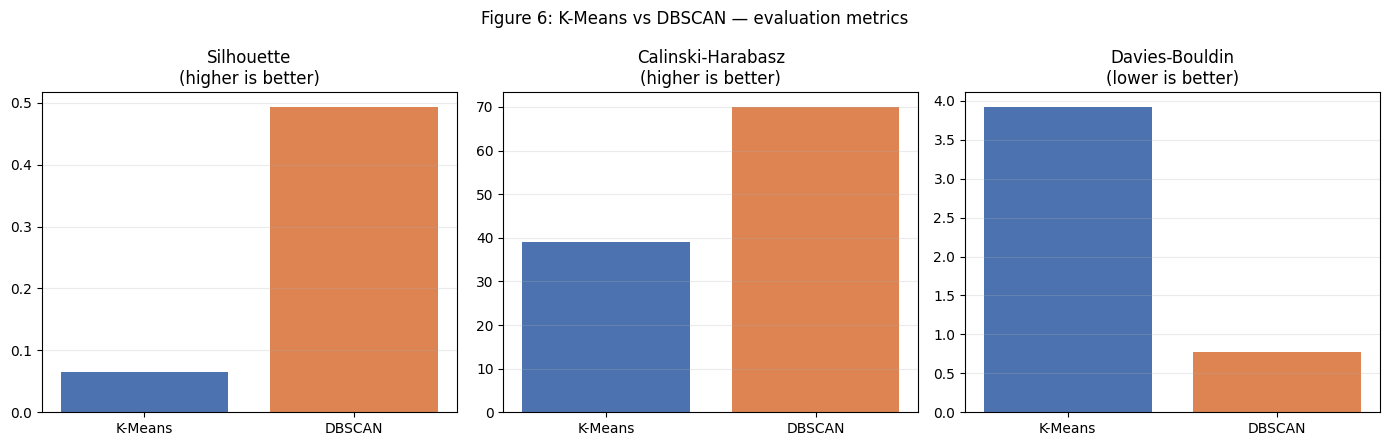

In [13]:
# Figure 6: grouped bar comparison of the three metrics (each on its own axis —
# never normalize Silhouette/CH/DB onto one scale, their ranges are not comparable).
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
directions = ['higher is better', 'higher is better', 'lower is better']
colors = ['#4C72B0', '#DD8452']

for ax, metric, direction in zip(axes, metrics, directions):
    ax.bar(results['Method'], results[metric], color=colors)
    ax.set_title(f'{metric}\n({direction})')
    ax.grid(alpha=0.25, axis='y')

plt.suptitle('Figure 6: K-Means vs DBSCAN — evaluation metrics')
plt.tight_layout()
savefig('fig6_metric_comparison.png')
plt.show()

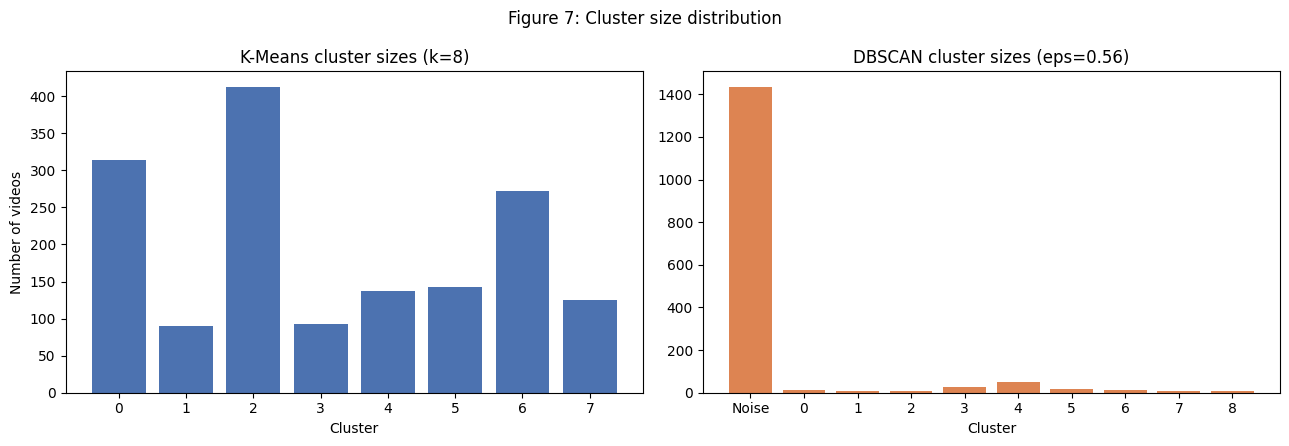

In [14]:
# Figure 7: cluster size distribution for both methods.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

km_sizes = pd.Series(labels_kmeans).value_counts().sort_index()
axes[0].bar(km_sizes.index.astype(str), km_sizes.values, color='#4C72B0')
axes[0].set_title(f'K-Means cluster sizes (k={best_k})')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of videos')

db_sizes = pd.Series(labels_dbscan).value_counts().sort_index()
db_labels_str = ['Noise' if i == -1 else str(i) for i in db_sizes.index]
axes[1].bar(db_labels_str, db_sizes.values, color='#DD8452')
axes[1].set_title(f'DBSCAN cluster sizes (eps={best_eps:.2f})')
axes[1].set_xlabel('Cluster')

plt.suptitle('Figure 7: Cluster size distribution')
plt.tight_layout()
savefig('fig7_cluster_sizes.png')
plt.show()

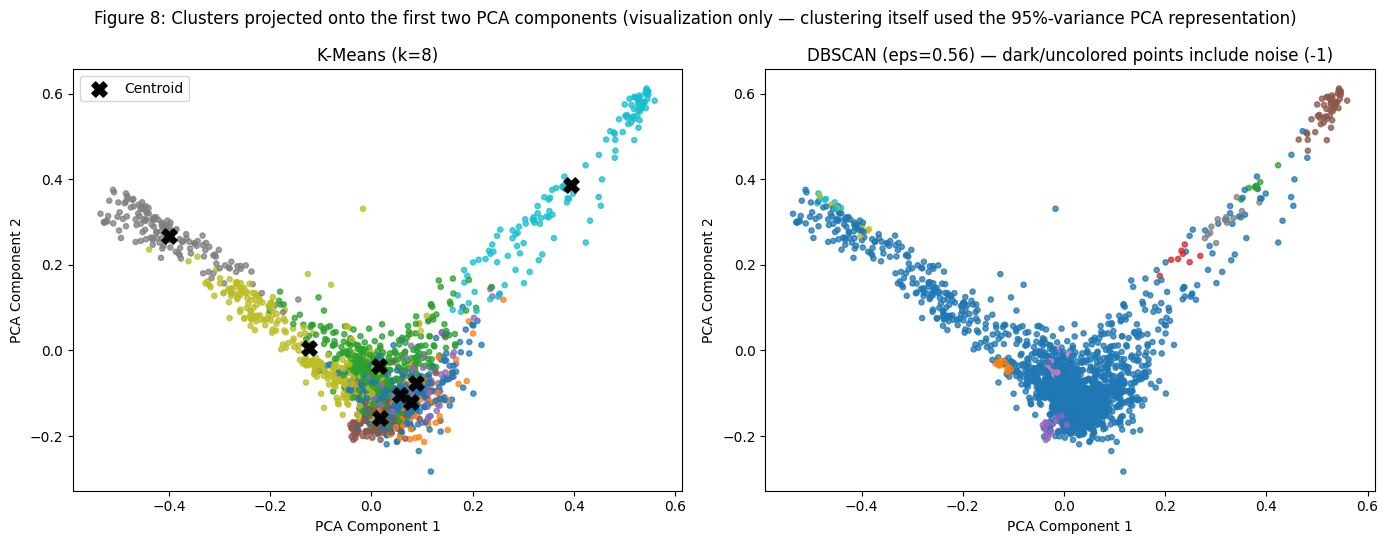

In [15]:
# Figure 8: 2D PCA visualization with centroids marked.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='tab10', s=14, alpha=0.75)
centroids_2d = np.array([X_2d[labels_kmeans == i].mean(axis=0) for i in range(best_k)])
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', marker='X', s=120, label='Centroid')
axes[0].set_title(f'K-Means (k={best_k})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_dbscan, cmap='tab10', s=14, alpha=0.75)
axes[1].set_title(f'DBSCAN (eps={best_eps:.2f}) — dark/uncolored points include noise (-1)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.suptitle('Figure 8: Clusters projected onto the first two PCA components (visualization only — '
             'clustering itself used the 95%-variance PCA representation)')
plt.tight_layout()
savefig('fig8_cluster_scatter.png')
plt.show()

## 9. Cluster themes: top TF-IDF terms and example captions

Numerical cluster quality metrics don't tell you *what* a cluster represents. This section
pulls the highest-weighted TF-IDF terms per cluster (from the original TF-IDF space, not the PCA
projection) and a few example videos, to check the clusters correspond to coherent caption
themes (people, sports, cooking, animals, etc.).

In [16]:
def top_terms_per_cluster(labels, X, top_n=8, exclude_noise=False):
    rows = []
    for lab in sorted(set(labels)):
        if exclude_noise and lab == -1:
            continue
        mask = labels == lab
        mean_vec = X[mask].mean(axis=0)
        top_idx = np.argsort(mean_vec)[::-1][:top_n]
        rows.append({'Cluster': lab, 'Size': int(mask.sum()), 'Top terms': ', '.join(feature_names[top_idx])})
    return pd.DataFrame(rows)

print('K-Means cluster themes:')
display(top_terms_per_cluster(labels_kmeans, X_dense))

print('\nDBSCAN cluster themes (noise excluded):')
display(top_terms_per_cluster(labels_dbscan, X_dense, exclude_noise=True))

K-Means cluster themes:


,Cluster,Size,Top terms
0,0,314,"baby, dog, playing, animal, eating, small, wal..."
1,1,90,"cat, cat playing, kitten, playing cat, playing..."
2,2,413,"man, men, person, people, boy, doing, talking,..."
3,3,93,"dancing, dance, danced, stage, dances, people ..."
4,4,137,"riding, man riding, bike, driving, horse, car,..."
5,5,142,"cutting, slicing, man cutting, knife, cuts, cu..."
6,6,272,"woman, girl, lady, women, man, cooking, making..."
7,7,125,"guitar, man playing, playing guitar, playing, ..."



DBSCAN cluster themes (noise excluded):


,Cluster,Size,Top terms
0,0,14,"makeup, applying, woman applying, eye, woman p..."
1,1,8,"guitar, playing guitar, girl playing, woman pl..."
2,2,8,"flute, flute man, playing flute, man playing, ..."
3,3,25,"horse, riding horse, riding, horse man, woman ..."
4,4,48,"guitar, guitar man, playing guitar, man playin..."
5,5,17,"shooting, gun, man shooting, gun man, shooting..."
6,6,14,"piano, playing piano, keyboard, man playing, p..."
7,7,8,"onion, slicing onion, onions, slicing, cutting..."
8,8,8,"potato, potatoes, slicing, cutting potato, cut..."


In [17]:
video_docs['KMeans_Cluster'] = labels_kmeans
video_docs['DBSCAN_Cluster'] = labels_dbscan

for c in sorted(video_docs['KMeans_Cluster'].unique()):
    print(f'\n=== K-Means Cluster {c} ===')
    subset = video_docs[video_docs['KMeans_Cluster'] == c]
    sample = subset.sample(min(5, len(subset)), random_state=RANDOM_STATE)
    for _, row in sample.iterrows():
        print(row['VideoID'], ':', row['document'][:240], '...')


=== K-Means Cluster 0 ===
SULWQEAErKw : a huge turtle is walking on land a big turtle is walking a large turtle crawls in the grass a large turtle is walking on a muddy patch and then onto a grassy land a turtle is quickly walking along the ground a turtle is walking across the g ...
4t5POXt2e68 : a crying baby falls down a small boy is laughing too much a baby is crying a baby is laughing and falling back a giggling baby falls over a baby is falling over from laughing a baby laughs so hard he falls over a baby is laughing a baby is  ...
j4dMnAPZu70 : a panda slides down a slide on his stomach and lands in the snow a panda rides a slide a baby panda rides down a slide a panda is sliding in the ice a panda is playing a baby panda slides down a wooden slide a baby panda is going down a sli ...
9HDUADeA2xg : a puppy plays with a ball a chihuahua plays with a tennis ball a dog is playing with a ball a dog plays with a ball a little dog is playing with a ball a puppy is playing with a ball

## 10. Automatic conclusion for the report

Do not claim one algorithm is universally better — the conclusion below is generated directly
from the metrics computed on this run, and the exact numbers will vary slightly between runs of
DBSCAN's eps search.

In [18]:
km = results[results['Method'] == 'K-Means'].iloc[0]
db = results[results['Method'] == 'DBSCAN'].iloc[0]

def better_method():
    # Simple rule: count how many of the 3 metrics favor each method; ties go to noise ratio.
    km_wins = int(km['Silhouette'] > db['Silhouette']) + \
              int(km['Calinski-Harabasz'] > db['Calinski-Harabasz']) + \
              int(km['Davies-Bouldin'] < db['Davies-Bouldin'])
    return 'K-Means' if km_wins >= 2 else 'DBSCAN'

winner = better_method()

print('REPORT CONCLUSION')
print('-----------------')
print(f'The MSVD caption corpus was transformed into one text document per video ({len(video_docs)} videos).')
print(f'TF-IDF produced {X_dense.shape[1]} features, reduced by PCA to {X_pca.shape[1]} components '
      f'while retaining {pca_full.explained_variance_ratio_.sum()*100:.2f}% variance '
      f'(95% target reached at {n95} components on the full scree curve).')
print(f'K-Means (k={best_k}, selected via silhouette) produced {int(km["Clusters"])} clusters: '
      f'Silhouette={km["Silhouette"]}, CH={km["Calinski-Harabasz"]}, DB={km["Davies-Bouldin"]}.')
print(f'DBSCAN (eps={best_eps:.3f}, min_samples={MIN_SAMPLES}, selected via k-distance knee + silhouette '
      f'refinement) produced {int(db["Clusters"])} non-noise clusters: '
      f'Silhouette={db["Silhouette"]}, CH={db["Calinski-Harabasz"]}, DB={db["Davies-Bouldin"]}, '
      f'{db["Noise %"]}% noise.')
print(f'By majority vote across the three internal validation metrics, {winner} produced the '
      f'stronger clustering structure for this dataset and preprocessing pipeline. This result is '
      f'specific to this configuration, not a general claim about either algorithm.')

REPORT CONCLUSION
-----------------
The MSVD caption corpus was transformed into one text document per video (1586 videos).
TF-IDF produced 500 features, reduced by PCA to 308 components while retaining 95.03% variance (95% target reached at 308 components on the full scree curve).
K-Means (k=8, selected via silhouette) produced 8 clusters: Silhouette=0.0657, CH=38.96, DB=3.9156.
DBSCAN (eps=0.562, min_samples=8, selected via k-distance knee + silhouette refinement) produced 9 non-noise clusters: Silhouette=0.4924, CH=69.9, DB=0.7711, 90.54% noise.
By majority vote across the three internal validation metrics, DBSCAN produced the stronger clustering structure for this dataset and preprocessing pipeline. This result is specific to this configuration, not a general claim about either algorithm.


## 11. What to submit in the PDF

**1. Dataset suitability:** MSVD is the corpus used in the video-captioning research project;
captions provide high-dimensional text features suitable for clustering (Section 1).

**2. Dimensionality reduction:** TF-IDF → PCA, justified with the scree curve (Figure 2), not
just an assertion. Report the original feature count, retained components, and retained variance
from your actual Colab output.

**3. Clustering:** K-Means selected via elbow + silhouette (Figure 3, 4); DBSCAN selected via
k-distance knee + silhouette refinement (Figure 5). Report the selected `k`, `eps`, `min_samples`.

**4. Evaluation:** Table from Section 8 + Figure 6. Remember: Silhouette/CH higher is better,
Davies-Bouldin lower is better.

**5. Screenshots (recommended, ~7):** dataset load (Section 2 output), Figure 2 (PCA scree),
Figure 3+4 (K-Means selection), Figure 5 (DBSCAN k-distance), evaluation table + Figure 6,
Figure 8 (cluster scatter), Section 9 cluster-theme table.

**6. GitHub:** push this notebook and paste the repository URL in the PDF.